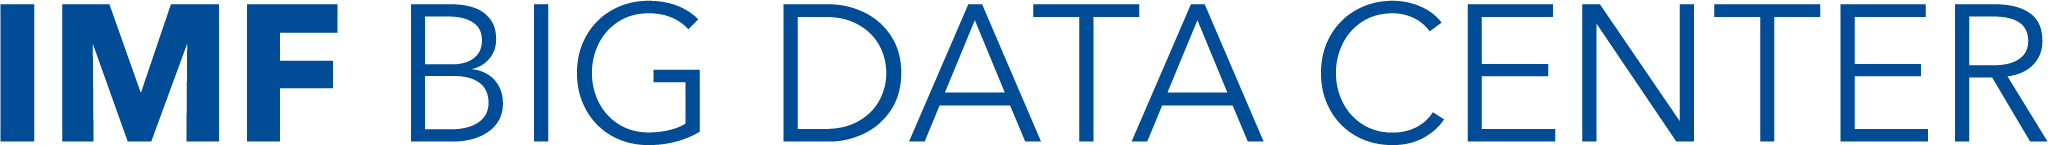

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AlessandraSozzi/STI_2026/blob/main/notebooks/BDC_Builtup_statistics_from_satellite_imageries.ipynb)

# Building statistics from satellite imageries
Useful links and references


---

<br>**Contributors:** [Alessandra Sozzi](asozzi@imf.org) & [Mario Saraiva](msaraiva@imf.org)
<br> **Last update:** Oct-2025
<br> **Description:** This notebook showcase methods to derive builtup area and building footprints statistics and from satellite imageries.
<br> **References:**

Useful links and references

- [Google Earth Engine](https://earthengine.google.com/)
- [Create a google / gmail account if you do not have one already](https://support.google.com/mail/answer/56256?hl=en)
- [Try to log-on to google colab account with you gmail account](https://colab.research.google.com/)
- [Sign up for an Earth Engine account](https://earthengine.google.com/signup/)
- [Geemap website](https://geemap.org/)
- [Geemap book](https://book.geemap.org/)
- [Geemap YouTube videos](https://youtube.com/@giswqs)
- [Learn more about Google Earth Engine, usage and applications](https://courses.spatialthoughts.com/end-to-end-gee.html)
- [Dynamic World](https://dynamicworld.app/)
- [Explore Dynamic World data exploration tool here](https://dynamicworld.app/explore)
- [Microsoft Global ML Building Footprints](https://github.com/microsoft/GlobalMLBuildingFootprints)
- [H3: Uber’s Hexagonal Hierarchical Spatial Index](https://h3geo.org/)
- [Overture Maps Foundation](https://overturemaps.org/)

## Setup

#### Mount the drive and adjust the path

In [ ]:
# Mounth the drive to access file in the Google Drive folder
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
# Set the main path for the workshop files
import os

ROOT = "/content/drive/MyDrive/STI_2026"
workshop_path = os.path.join(ROOT, "Day 2 - Satellite Data Fundamentals/Built-up Statistics")
data_path = os.path.join(workshop_path, "data")

# Check if working
print("Worshop path found: ", os.path.exists(workshop_path))
print("Data path found: ", os.path.exists(data_path))

Worshop path found:  True
Data path found:  True


### Authenticate Google Earth Engine

In [ ]:
import ee
ee.Authenticate()
my_project_name = 'ee-bigdatacenter-1' # USE YOUR OWN GOOGLE CLOUD PROJECT
ee.Initialize(project=my_project_name)

### Libraries

In [ ]:
import geemap

import pandas as pd
import geopandas as gpd

import matplotlib.pyplot as plt

# **Built-up area Statistics**

In this section, we will derive crop-land statistics using **Google Dynamic World** global land-cover dataset.

## Google Dynamic World

Dynamic World LULC is a near realtime 10m resolution global land use land cover dataset, produced using deep learning and sentinel-2 High-frequency imagery. It is freely available and openly licensed.
- [Dynamic World Website](https://www.dynamicworld.app/)
- [Dynamic World datasets on Earth Engine](https://developers.google.com/earth-engine/datasets/catalog/GOOGLE_DYNAMICWORLD_V1)

> Pasquarella, V. et al. "Dynamic World: Near real-time global 10 m land use land cover mapping." Nature Scientific Data (2022). https://www.nature.com/articles/s41597-022-01307-4

### 🏙️ **What defines built up areas in land cover maps?**

**Definition:**  
Areas dominated by **human-made structures and surfaces**, such as buildings, paved roads, parking lots, runways, and other impervious materials. These are typically **urban or industrial zones** where artificial surfaces replace natural land cover.

**Includes:**  
- Residential, commercial, and industrial built-up areas  
- Transportation infrastructure (roads, railways, airports)  
- Urban open areas dominated by concrete or asphalt  

**Excludes:**  
- Bare soil or exposed ground (classified as **Bare**)  
- Sparse rural settlements where vegetation is dominant  
- Construction sites with visible soil (may appear as **Bare** or **Crops**)  

**Spectral characteristics:**  
Built surfaces generally show **high reflectance in visible wavelengths** (especially red) and **low reflectance in near-infrared (NIR)** bands, resulting in low vegetation indices (e.g., NDVI).

### Country for this Excercise

In [ ]:
country_name= "Lithuania"

### Extract Built-up Areas

In [ ]:
# Load GAUL 2024 L1 and filter by country name
country_l1 = (ee.FeatureCollection("projects/sat-io/open-datasets/FAO/GAUL/GAUL_2024_L1")
              .filter(ee.Filter.eq('gaul0_name', country_name)))

# Define the time range
start_date = ee.Date('2024-01-01')
end_date = ee.Date('2024-12-31')

# Load the Dynamic World dataset
dw = ee.ImageCollection("GOOGLE/DYNAMICWORLD/V1") \
    .filterDate(start_date, end_date) \
    .filterBounds(country_l1)

# Create a mode composite.
classification = dw.select('label');
dwComposite = classification.reduce(ee.Reducer.mode());

# Extract the Built Area class.
# See more https://developers.google.com/earth-engine/datasets/catalog/GOOGLE_DYNAMICWORLD_V1#bands
# The resulting builtArea image is a binary image—with pixel value 1
# where the condition matched and 0 where it didn't.
built_class = 6
builtArea = dwComposite.eq(built_class)

We can add both the composite and the built area images to the Map to verify it.


In [ ]:
# Set the map
Map = geemap.Map()
Map.centerObject(country_l1, 7);

# DW class colors
dwVisParams = {
  'min': 0,
  'max': 8,
  'palette': [
    '#419BDF', '#397D49', '#88B053', '#7A87C6', '#E49635', '#DFC35A',
    '#C4281B', '#A59B8F', '#B39FE1'
  ]
};

dwBuiltMaskParams = {
      'min': 0,
      'max': 1,
      'palette': ["white", "red"]
}

# Add the composite and the built mask to the map
Map.addLayer(dwComposite.clip(country_l1), dwVisParams, 'Classified Composite');
Map.addLayer(builtArea.clip(country_l1),  dwBuiltMaskParams, 'Built Areas');
Map

Map(center=[41.130404045317334, 20.06641191545739], controls=(WidgetControl(options=['position', 'transparent_…

###  Calculate zonal statistics

In [ ]:
builtArea = (dwComposite
             .eq(built_class) # equal to built class
             .clipToCollection(country_l1)
             .selfMask()) # keep only pixels that match condition
nonBuiltArea = (dwComposite
                .neq(built_class)  # NOT equal to built class
                .clipToCollection(country_l1)
                .selfMask()) # keep only pixels that match condition

In [ ]:
images = ee.List([nonBuiltArea, builtArea])
collection = ee.ImageCollection.fromImages(images)
collection = collection.toBands().rename(['non_built_area', 'built_area'])

In [ ]:
# Zonal statistics by region
geemap.zonal_stats(
    collection,                  # Raster layer
    country_l1,                   # Vector features (L1 regions)
    os.path.join(data_path, 'dynamic_world_bulit.csv'),           # Output filepath
    statistics_type='SUM',        # Sum of pixels
    scale=1000,                   # Spatial resolution
    verbose=True,
)

Computing statistics ...
Generating URL ...
Please wait ...
Data downloaded to /content/drive/MyDrive/STI_2026/Day 2 - Satellite Data Fundamentals/Built-up Statistics/data/dynamic_world_bulit.csv


In [ ]:
# let's map it to a dataframe using the geemap tool
df = geemap.csv_to_df(os.path.join(data_path, 'dynamic_world_bulit.csv'))

# Calculate built area percentage
df['percentage_built_area'] = df['built_area']*100 / (df['built_area'] + df['non_built_area'])

df.head(10)


,non_built_area,built_area,gaul0_name,continent,iso3_code,disp_en,map_code,gaul1_code,gaul0_code,gaul1_name,system:index,percentage_built_area
0,2287.654902,107.121569,Albania,Europe,ALB,"Berat, Albania",ALB,3291,284,Berat,0000000000000000027f,4.473134
1,3274.913725,46.000000,Albania,Europe,ALB,"Diber, Albania",ALB,3292,284,Diber,00000000000000000280,1.385161
2,835.698039,205.384314,Albania,Europe,ALB,"Durres, Albania",ALB,3293,284,Durres,00000000000000000281,19.727960
3,4150.364706,204.890196,Albania,Europe,ALB,"Elbasan, Albania",ALB,3294,284,Elbasan,00000000000000000282,4.704436
4,2241.733333,237.611765,Albania,Europe,ALB,"Fier, Albania",ALB,3295,284,Fier,00000000000000000283,9.583650
5,3758.462745,47.000000,Albania,Europe,ALB,"Gjirokaster, Albania",ALB,3296,284,Gjirokaster,00000000000000000284,1.235067
6,4866.427451,95.000000,Albania,Europe,ALB,"Korce, Albania",ALB,3297,284,Korce,00000000000000000285,1.914772
7,3228.407843,33.000000,Albania,Europe,ALB,"Kukes, Albania",ALB,3298,284,Kukes,00000000000000000286,1.011833
8,2064.917647,129.486275,Albania,Europe,ALB,"Lezhe, Albania",ALB,3299,284,Lezhe,00000000000000000287,5.900749
9,4558.235294,181.035294,Albania,Europe,ALB,"Shkoder, Albania",ALB,3300,284,Shkoder,00000000000000000288,3.819898


In [ ]:
# Bar chart of built area per region
geemap.bar_chart(
    df,
    x='gaul1_name', y='percentage_built_area',
    max_rows=50,
    x_label='',
    y_label='Builtup Area %'
)

# **Building Footprints**


## 🏗️ **What defines Building Footprints?**

**Building footprints** are polygon representations of the exact ground area covered by built structures such as houses, commercial buildings, and other man-made constructions. They provide a detailed, vector-based view of human settlements and are a key layer for understanding **urbanization, population distribution, and land-use change**.  

Building footprint datasets are typically derived from **high-resolution satellite imagery, aerial photos, or LiDAR data** using machine-learning and computer-vision methods. Global initiatives such as **Microsoft’s Global ML Building Footprints**, **Google Open Buildings**, and **Overture Maps** have made large-scale, open datasets available for urban analytics, disaster risk assessment, and infrastructure planning.

## Microsoft’s Global ML Building Footprints

The **Microsoft Global Building Footprints** dataset provides detailed polygon representations of individual buildings derived from high-resolution satellite imagery using deep learning. As of 2024, Microsoft has released over **1.4 billion building footprints** across multiple continents, freely available under the **Open Data Commons Open Database License (ODbL)**.

> **Source:** [Microsoft Global ML Building Footprints](https://github.com/microsoft/GlobalMLBuildingFootprints)

In [ ]:
%%capture
!pip install h3

In [ ]:
%%capture
!pip install mapclassify

In [ ]:
%%capture
!pip install mercantile

In [ ]:
import h3

import tempfile
import mercantile
import pandas as pd
import geopandas as gpd
from shapely import geometry

### Define our area of interest (AOI)


In [ ]:
country_name = "Lithuania"
iso3 = "LTU"

In [ ]:
# Define the URL for the Albania Admin 0 boundaries GeoJSON
url_l0 = f"https://geodata.ucdavis.edu/gadm/gadm4.1/json/gadm41_{iso3}_0.json.zip"

# Read the GeoJSON data using geopandas
country_l0 = gpd.read_file(url_l0)

country_l0.explore()

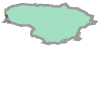

In [ ]:
aoi_shape = geometry.shape(country_l0.iloc[0].geometry)
aoi_shape

In [ ]:
minx, miny, maxx, maxy = aoi_shape.bounds
print(minx, miny, maxx, maxy)

20.9506 53.8901 26.8472 56.447


### Determine which tiles intersect our AOI

In [ ]:
quad_keys = set()
for tile in list(mercantile.tiles(minx, miny, maxx, maxy, zooms=9)):
    quad_keys.add(mercantile.quadkey(tile))
quad_keys = list(set(quad_keys))
print(f"The input area spans {len(quad_keys)} tiles: {quad_keys}")

The input area spans 70 tiles: ['120300200', '120300031', '120033321', '120300010', '120300101', '120300022', '120122320', '120300130', '120300310', '120122220', '120211110', '120300110', '120211311', '120122322', '120300121', '120211113', '120300011', '120122332', '120300003', '120211101', '120211111', '120300001', '120300201', '120122232', '120300030', '120211112', '120122230', '120211310', '120300021', '120300033', '120300032', '120300112', '120300000', '120122222', '120300002', '120300211', '120211132', '120122221', '120122321', '120211301', '120300120', '120122231', '120122323', '120122223', '120211131', '120211130', '120211133', '120300020', '120122330', '120300301', '120211103', '120300013', '120300123', '120033333', '120033330', '120033332', '120122233', '120033331', '120300100', '120300210', '120033323', '120211121', '120300122', '120300132', '120211123', '120300102', '120300012', '120300023', '120300103', '120300300']


### Download the building footprints for each tile and keep building that fell between the specified country boundary (L0)

In [ ]:
df = pd.read_csv(
    "https://minedbuildings.z5.web.core.windows.net/global-buildings/dataset-links.csv", dtype=str
)
df.drop_duplicates(subset=['QuadKey'], inplace=True)
df.set_index('QuadKey', inplace=True)
df.head()

,Location,Url,Size,UploadDate
QuadKey,,,,
122320113,Abyei,https://minedbuildings.z5.web.core.windows.net...,74.5KB,2025-02-28
122320131,Abyei,https://minedbuildings.z5.web.core.windows.net...,8.3KB,2025-02-28
122321002,Abyei,https://minedbuildings.z5.web.core.windows.net...,392.2KB,2025-02-28
122321003,Abyei,https://minedbuildings.z5.web.core.windows.net...,72.8KB,2025-02-28
122321020,Abyei,https://minedbuildings.z5.web.core.windows.net...,1.2MB,2025-02-28


In [ ]:
quad_keys = df[df.Location == country_name].index.tolist() # 120033333

In [ ]:
idx = 0
combined_gdf = gpd.GeoDataFrame()
with tempfile.TemporaryDirectory() as tmpdir:
    # Download the GeoJSON files for each tile that intersects the input geometry
    tmp_fns = []
    for i, quad_key in enumerate(quad_keys):
        print(f"Processing tile: {quad_key}")

        try:
          url = df.loc[quad_key].Url
        except KeyError:
          print(f"No footprints found for tile: {quad_key}")
          continue

        df2 = pd.read_json(url, lines=True)
        df2["geometry"] = df2["geometry"].apply(geometry.shape)

        gdf = gpd.GeoDataFrame(df2, crs=4326)
        fn = os.path.join(tmpdir, f"{quad_key}.geojson")
        tmp_fns.append(fn)
        if not os.path.exists(fn):
            gdf.to_file(fn, driver="GeoJSON")


    # Merge the GeoJSON files into a single file
    for fn in tmp_fns:
        gdf = gpd.read_file(fn)  # Read each file into a GeoDataFrame
        gdf = gdf[gdf.geometry.within(aoi_shape)]  # Filter geometries within the AOI
        gdf['id'] = range(idx, idx + len(gdf))  # Update 'id' based on idx
        idx += len(gdf)
        combined_gdf = pd.concat([combined_gdf,gdf],ignore_index=True)

Processing tile: 120033332
Processing tile: 120122222
Processing tile: 120122223
Processing tile: 120122232
Processing tile: 120211103
Processing tile: 120211110
Processing tile: 120211111
Processing tile: 120211112
Processing tile: 120211113
Processing tile: 120300000
Processing tile: 120300001
Processing tile: 120300002
Processing tile: 120300003
Processing tile: 120300010
Processing tile: 120300011
Processing tile: 120300012
Processing tile: 120300013
Processing tile: 120300020
Processing tile: 120300021
Processing tile: 120300022
Processing tile: 120300023
Processing tile: 120300030
Processing tile: 120300031
Processing tile: 120300032
Processing tile: 120300100
Processing tile: 120300102


In [ ]:
df[df.QuadKeys=='120033333']

AttributeError: 'DataFrame' object has no attribute 'QuadKeys'

In [ ]:
combined_gdf.head()

,type,properties,geometry,id
0,Feature,"{ ""height"": -1.0, ""confidence"": -1.0 }","POLYGON ((24.61057 54.78643, 24.6107 54.78648,...",0
1,Feature,"{ ""height"": -1.0, ""confidence"": -1.0 }","POLYGON ((24.6125 54.78271, 24.61264 54.78263,...",1
2,Feature,"{ ""height"": -1.0, ""confidence"": -1.0 }","POLYGON ((24.61284 54.75943, 24.61279 54.75954...",2
3,Feature,"{ ""height"": -1.0, ""confidence"": -1.0 }","POLYGON ((24.61287 54.86197, 24.61284 54.86202...",3
4,Feature,"{ ""height"": -1.0, ""confidence"": -1.0 }","POLYGON ((24.61357 54.78348, 24.61368 54.78353...",4


In [ ]:
combined_gdf.shape

(1677216, 4)

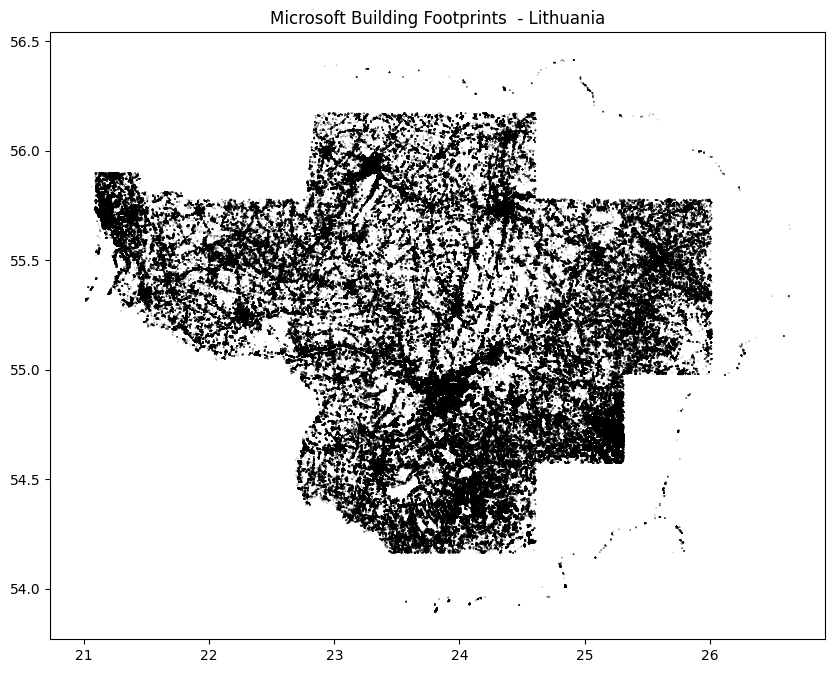

In [ ]:
# Plot the building footprints
combined_gdf.plot(figsize=(10, 10), edgecolor="black", facecolor="lightblue")

# # Show the plot
plt.title("Microsoft Building Footprints  - " + country_name)
plt.show()

In [ ]:
combined_gdf.head()

,type,properties,geometry,id
0,Feature,"{ ""height"": -1.0, ""confidence"": -1.0 }","POLYGON ((19.67934 42.59883, 19.67935 42.59893...",0
1,Feature,"{ ""height"": -1.0, ""confidence"": -1.0 }","POLYGON ((19.66186 42.59933, 19.66182 42.59936...",1
2,Feature,"{ ""height"": -1.0, ""confidence"": -1.0 }","POLYGON ((19.68427 42.59035, 19.68432 42.59046...",2
3,Feature,"{ ""height"": -1.0, ""confidence"": -1.0 }","POLYGON ((19.66398 42.59922, 19.66383 42.59926...",3
4,Feature,"{ ""height"": -1.0, ""confidence"": -1.0 }","POLYGON ((19.65577 42.60543, 19.65576 42.60548...",4


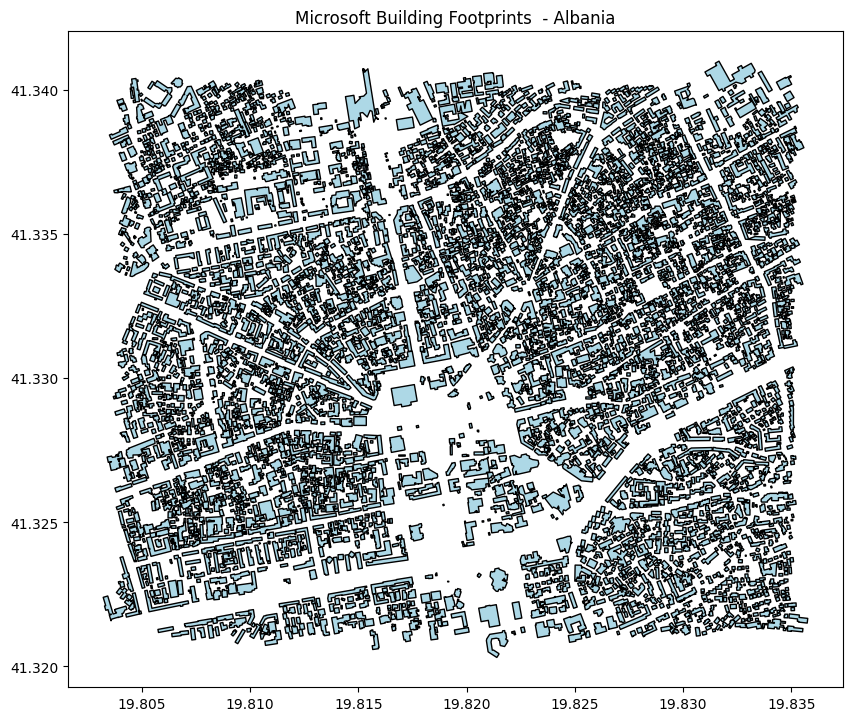

In [ ]:
# Let's define a smaller area around Tirana city center. You can use this tool to define a bounding box https://boundingbox.klokantech.com/
xmin = 19.8041909995
xmax = 19.8350096801
ymin = 41.3212143521
ymax = 41.3400916172

# Plot the building footprints filtered within the bounding box
combined_gdf.cx[xmin:xmax, ymin:ymax].plot(figsize=(10, 10),
                  edgecolor="black",
                  facecolor="lightblue")

# # Show the plot
plt.title("Microsoft Building Footprints  - " + country_name)
plt.show()

### Count buildings whithin each L2 region

In [ ]:
url_l3 = f"https://geodata.ucdavis.edu/gadm/gadm4.1/json/gadm41_{iso3}_3.json.zip"

# Read the GeoJSON data using geopandas
country_l3 = gpd.read_file(url_l3)

# Number of regions
print(country_l3.shape)

country_l3.explore()

(378, 17)


In [ ]:
combined_gdf['GID_3'] = None
combined_gdf['NAME_1'] = None
combined_gdf['NAME_2'] = None
combined_gdf['NAME_3'] = None

for i, row in country_l3.iterrows():
    print(f"Processing id {i}: {row.NAME_3}")
    filtered = combined_gdf[combined_gdf.within(row.geometry)]
    combined_gdf.loc[filtered.index, 'GID_3'] = row.GID_3
    combined_gdf.loc[filtered.index, 'NAME_1'] = row.NAME_1
    combined_gdf.loc[filtered.index, 'NAME_2'] = row.NAME_2
    combined_gdf.loc[filtered.index, 'NAME_3'] = row.NAME_3

Processing id 0: Berat
Processing id 1: Cukalat
Processing id 2: Kutalli
Processing id 3: Lumas
Processing id 4: Otllak
Processing id 5: Poshnjë
Processing id 6: Roshnik
Processing id 7: Sinjë
Processing id 8: Tërpan
Processing id 9: UraVajgurorë
Processing id 10: Velabisht
Processing id 11: Vertop
Processing id 12: Kozarë
Processing id 13: Kuçovë
Processing id 14: Perondi
Processing id 15: Bogovë
Processing id 16: Çepan
Processing id 17: Çorovodë
Processing id 18: Gjerbes
Processing id 19: Leshnjë
Processing id 20: Poliçan
Processing id 21: Potom
Processing id 22: Qendër
Processing id 23: Vendreshë
Processing id 24: Zhepë
Processing id 25: Bulqizë
Processing id 26: FushëBulqizë
Processing id 27: Gjoricë
Processing id 28: Ostren
Processing id 29: Shupenzë
Processing id 30: Steblevë
Processing id 31: Trebisht
Processing id 32: Zerqan
Processing id 33: Arras
Processing id 34: FushëÇidhen
Processing id 35: KalaeDodës
Processing id 36: Kastriot
Processing id 37: Lurë
Processing id 38: Luzn

In [ ]:
combined_gdf.head()

,type,properties,geometry,id,GID_3,NAME_1,NAME_2,NAME_3
0,Feature,"{ ""height"": -1.0, ""confidence"": -1.0 }","POLYGON ((19.67934 42.59883, 19.67935 42.59893...",0,ALB.10.1.4_1,Shkodër,MalësieMadhe,Kelmend
1,Feature,"{ ""height"": -1.0, ""confidence"": -1.0 }","POLYGON ((19.66186 42.59933, 19.66182 42.59936...",1,ALB.10.1.4_1,Shkodër,MalësieMadhe,Kelmend
2,Feature,"{ ""height"": -1.0, ""confidence"": -1.0 }","POLYGON ((19.68427 42.59035, 19.68432 42.59046...",2,ALB.10.1.4_1,Shkodër,MalësieMadhe,Kelmend
3,Feature,"{ ""height"": -1.0, ""confidence"": -1.0 }","POLYGON ((19.66398 42.59922, 19.66383 42.59926...",3,ALB.10.1.4_1,Shkodër,MalësieMadhe,Kelmend
4,Feature,"{ ""height"": -1.0, ""confidence"": -1.0 }","POLYGON ((19.65577 42.60543, 19.65576 42.60548...",4,ALB.10.1.4_1,Shkodër,MalësieMadhe,Kelmend


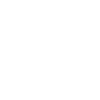

In [ ]:
combined_gdf.iloc[0].geometry

In [ ]:
n_buildings_by_region = (
    country_l3.merge(
        combined_gdf.groupby(['GID_3', 'NAME_3']).size().reset_index(name='n_buildings'),
        on=['GID_3', 'NAME_3'],
        how='left'
    )

)
n_buildings_by_region.head()

,GID_3,GID_0,COUNTRY,GID_1,NAME_1,NL_NAME_1,GID_2,NAME_2,NL_NAME_2,NAME_3,VARNAME_3,NL_NAME_3,TYPE_3,ENGTYPE_3,CC_3,HASC_3,geometry,n_buildings
0,ALB.1.1.1_1,ALB,Albania,ALB.1_1,Berat,NA,ALB.1.1_1,Beratit,NA,Berat,NA,NA,NA,NA,NA,NA,"MULTIPOLYGON (((19.9577 40.7212, 19.96 40.7107...",5804
1,ALB.1.1.2_1,ALB,Albania,ALB.1_1,Berat,NA,ALB.1.1_1,Beratit,NA,Cukalat,NA,NA,NA,NA,NA,NA,"MULTIPOLYGON (((19.825 40.6874, 19.8219 40.682...",2206
2,ALB.1.1.3_1,ALB,Albania,ALB.1_1,Berat,NA,ALB.1.1_1,Beratit,NA,Kutalli,NA,NA,NA,NA,NA,NA,"MULTIPOLYGON (((19.8027 40.7619, 19.7978 40.75...",7786
3,ALB.1.1.4_1,ALB,Albania,ALB.1_1,Berat,NA,ALB.1.1_1,Beratit,NA,Lumas,NA,NA,NA,NA,NA,NA,"MULTIPOLYGON (((20.0188 40.8759, 20.0132 40.86...",2906
4,ALB.1.1.5_1,ALB,Albania,ALB.1_1,Berat,NA,ALB.1.1_1,Beratit,NA,Otllak,NA,NA,NA,NA,NA,NA,"MULTIPOLYGON (((19.9577 40.7212, 19.9504 40.72...",7846


In [ ]:
# List Top 10 regions by count of buildings
n_buildings_by_region.sort_values(by='n_buildings', ascending=False)[['GID_3', 'NAME_2', 'NAME_3', 'n_buildings']].head(10)

,GID_3,NAME_2,NAME_3,n_buildings
346,ALB.11.2.15_1,Tiranës,Tiranë,37156
61,ALB.3.1.1_1,Durrësit,Durrës,24741
377,ALB.12.3.13_1,Vlorës,Vlorë,16704
337,ALB.11.2.6_1,Tiranës,Kamëz,15615
80,ALB.4.1.4_1,Elbasanit,Elbasan,13297
313,ALB.10.3.9_1,Shkodrës,Rrethina,12265
341,ALB.11.2.10_1,Tiranës,Paskuqan,12187
315,ALB.10.3.11_1,Shkodrës,Shkodër,12124
338,ALB.11.2.7_1,Tiranës,Kashar,11213
336,ALB.11.2.5_1,Tiranës,Farkë,10939


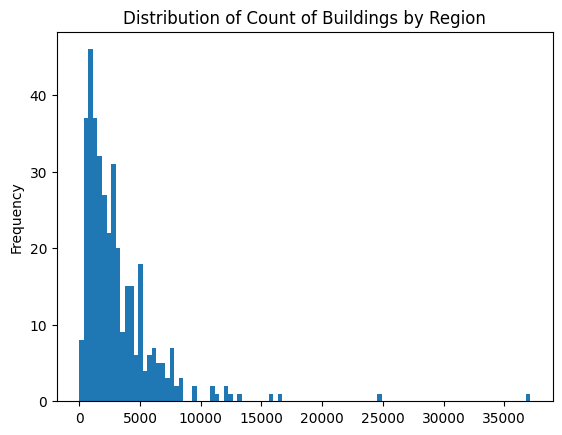

In [ ]:
# Plot distribution of counts
n_buildings_by_region.n_buildings.plot.hist(bins=100, title="Distribution of Count of Buildings by Region");

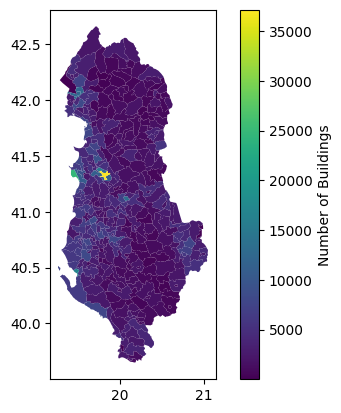

In [ ]:
# Plot values on a map
n_buildings_by_region.plot(column="n_buildings",
                           legend=True,
                           legend_kwds={"label": "Number of Buildings"});

### H3 binning

## 🧩 **H3 Spatial Indexing**

**H3** is a hierarchical, hexagon-based **spatial indexing system** developed by Uber for efficiently representing and analyzing geospatial data. It divides the Earth’s surface into a continuous grid of **hexagonal cells** (and a few pentagons) at multiple resolutions, from coarse (global) to fine (sub-meter). Each hexagon is assigned a unique **H3 index**, allowing complex spatial operations—such as aggregation, proximity analysis, and spatial joins—to be performed quickly and at scale.  

Unlike square grids, hexagons minimize edge effects and provide more uniform adjacency, making H3 particularly useful for **big geospatial data**, **mobility analytics**, **raster-to-vector transformations**, and **spatial downscaling or upscaling**. The indexing hierarchy (resolutions 0–15) supports seamless zooming and consistent spatial partitioning across datasets.

> **Reference:** [H3: Uber’s Hexagonal Hierarchical Spatial Index](https://h3geo.org/)

In [ ]:
h3_level = 10 # ≈ 13.6 km²

# Convert lat/long centroids of each building footprint into the coresponding h3 cell ID
def lat_lng_to_h3(row):
    return h3.latlng_to_cell(
      row.geometry.centroid.y, row.geometry.centroid.x, h3_level)

combined_gdf[f'h3_level_{h3_level}'] = combined_gdf.apply(lat_lng_to_h3, axis=1)


In [ ]:
# Count number of buildings by H3 cell
n_buildings_by_h3 = (
    combined_gdf.groupby(['NAME_3', f'h3_level_{h3_level}']).size().reset_index(name='n_buildings')
)

print(n_buildings_by_h3.shape)

n_buildings_by_h3.head()

(190999, 3)


,NAME_3,h3_level_10,n_buildings
0,Aliko,8a1ed048a4c7fff,3
1,Aliko,8a1ed048a4cffff,11
2,Aliko,8a1ed048a4dffff,7
3,Aliko,8a1ed048a797fff,1
4,Aliko,8a1ed048ac97fff,1


In [ ]:
# Add geometry of the hexbins
n_buildings_by_h3['geometry'] = n_buildings_by_h3.h3_level_10.apply(lambda x: h3.cells_to_geo([x]))
n_buildings_by_h3['geometry'] = n_buildings_by_h3['geometry'].apply(geometry.shape)

# Convert into geopandas dataframe
n_buildings_by_h3_geo = gpd.GeoDataFrame(
    n_buildings_by_h3,
    geometry='geometry',
    crs=4326
)

n_buildings_by_h3_geo.head()

,NAME_3,h3_level_10,n_buildings,geometry
0,Aliko,8a1ed048a4c7fff,3,"POLYGON ((20.09635 39.85483, 20.09697 39.85429..."
1,Aliko,8a1ed048a4cffff,11,"POLYGON ((20.0998 39.85469, 20.09918 39.85523,..."
2,Aliko,8a1ed048a4dffff,7,"POLYGON ((20.09697 39.85429, 20.09665 39.85361..."
3,Aliko,8a1ed048a797fff,1,"POLYGON ((20.0998 39.85469, 20.09947 39.85401,..."
4,Aliko,8a1ed048ac97fff,1,"POLYGON ((20.08865 39.86261, 20.08927 39.86207..."


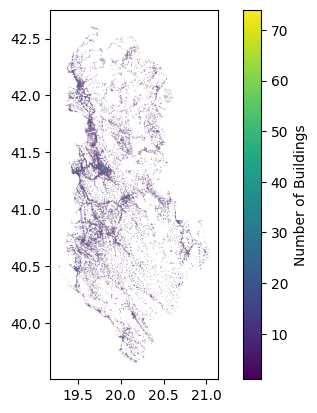

In [ ]:
# Plot number of buildings by h3 on a map
n_buildings_by_h3_geo.plot(column="n_buildings",
                           legend=True,
                           legend_kwds={"label": "Number of Buildings"});

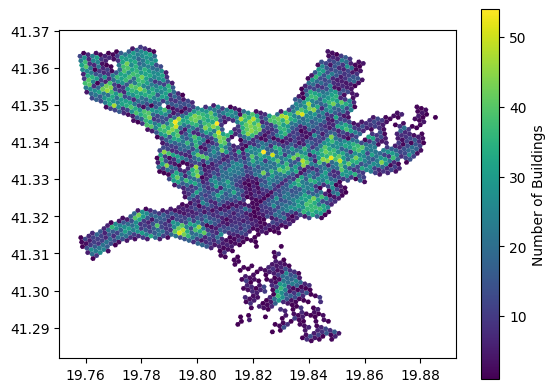

In [ ]:
# Plot number of buildings by h3 on a map: smaller region
n_buildings_by_h3_geo[n_buildings_by_h3_geo.NAME_3 == "Tiranë"].plot(column="n_buildings",
                           legend=True,
                           legend_kwds={"label": "Number of Buildings"});

## Overture Maps

**Overture Maps** is an open, collaborative mapping project founded by the **Overture Maps Foundation**, a nonprofit initiative led by **Linux Foundation** members including **Microsoft, Meta, Amazon Web Services, and TomTom**. Its goal is to create high-quality, interoperable **open map data** that can serve as a reliable base layer for applications in navigation, urban planning, and geospatial analysis.  

Overture Maps aggregates and harmonizes data from multiple public and private sources — including **OpenStreetMap**, **government open data**, and partner contributions — into standardized global datasets such as **buildings**, **transportation networks**, **places of interest**, and **administrative boundaries**. Data is distributed in **GeoParquet** format for efficient cloud-native use, making it well-suited for large-scale analytics and integration with tools like **BigQuery**, **DuckDB**, or **GeoPandas**.  

> **Source:** [Overture Maps Foundation](https://overturemaps.org/)



In [ ]:
%%capture
!pip install mapclassify

In [ ]:
%%capture
!pip install overturemaps

In [ ]:
%%capture
!pip install h3

In [ ]:
import h3
import overturemaps
from shapely import wkb
from shapely import geometry

### Define our area of interest (AOI)


In [ ]:
iso3 = "USA"

# Define the URL for the Albania Admin 0 boundaries GeoJSON
url = f"https://geodata.ucdavis.edu/gadm/gadm4.1/json/gadm41_{iso3}_1.json.zip"

# Read the GeoJSON data using geopandas
country = gpd.read_file(url)

# Select specific region
aoi_shape = geometry.shape( country[country.NAME_1 == "DistrictofColumbia"].iloc[0].geometry)
aoi_shape

# Define Country Bounding Box
bbox = aoi_shape.bounds
bbox

(-77.1205, 38.8093, -76.9097, 38.9951)

In [ ]:
country[country.NAME_1 == "DistrictofColumbia"].explore()

### Download building footprints

In [ ]:
# Use the record_batch_reader method to pull the data into a PyArrow table.
# Specify we want to grab buildings data.
table = overturemaps.record_batch_reader("building", bbox).read_all()
table = table.combine_chunks()

In [ ]:
# convert to dataframe
overture_df = table.to_pandas()

# DataFrame to GeoDataFrame, set crs
overture_gdf = gpd.GeoDataFrame(
    overture_df,
    geometry=overture_df['geometry'].apply(wkb.loads),
    crs="EPSG:4326"
)

print(overture_gdf.shape)

overture_gdf.head()

(327902, 24)


,id,geometry,bbox,version,sources,level,subtype,class,height,names,...,min_height,min_floor,facade_color,facade_material,roof_material,roof_shape,roof_direction,roof_orientation,roof_color,roof_height
0,e9a2bb07-fb73-4223-be84-cac6a071422b,"POLYGON ((-77.12043 38.80945, -77.12094 38.809...","{'xmin': -77.12098693847656, 'xmax': -77.12042...",2,"[{'property': '', 'dataset': 'OpenStreetMap', ...",NaN,residential,apartments,12.766887,None,...,NaN,NaN,None,None,None,None,NaN,None,None,NaN
1,844d0da0-1b13-4ea6-9f9b-d3e25a1520dd,"POLYGON ((-77.12035 38.80977, -77.12087 38.809...","{'xmin': -77.12092590332031, 'xmax': -77.12035...",2,"[{'property': '', 'dataset': 'OpenStreetMap', ...",NaN,residential,apartments,11.504520,None,...,NaN,NaN,None,None,None,None,NaN,None,None,NaN
2,65d54353-a67b-48c8-abe0-9ca5566c1060,"POLYGON ((-77.12008 38.80928, -77.12007 38.809...","{'xmin': -77.12022399902344, 'xmax': -77.12007...",1,"[{'property': '', 'dataset': 'OpenStreetMap', ...",NaN,residential,terrace,NaN,None,...,NaN,NaN,None,None,None,None,NaN,None,None,NaN
3,94f8ad65-3b28-4924-8ad6-b4f6aa074d1f,"POLYGON ((-77.12021 38.80933, -77.12007 38.809...","{'xmin': -77.12020874023438, 'xmax': -77.12006...",1,"[{'property': '', 'dataset': 'OpenStreetMap', ...",NaN,residential,terrace,NaN,None,...,NaN,NaN,None,None,None,None,NaN,None,None,NaN
4,96b12cb2-3f09-46b9-b48a-d5f6a6d7e895,"POLYGON ((-77.12003 38.80942, -77.12002 38.809...","{'xmin': -77.12018585205078, 'xmax': -77.12001...",1,"[{'property': '', 'dataset': 'OpenStreetMap', ...",NaN,residential,terrace,NaN,None,...,NaN,NaN,None,None,None,None,NaN,None,None,NaN


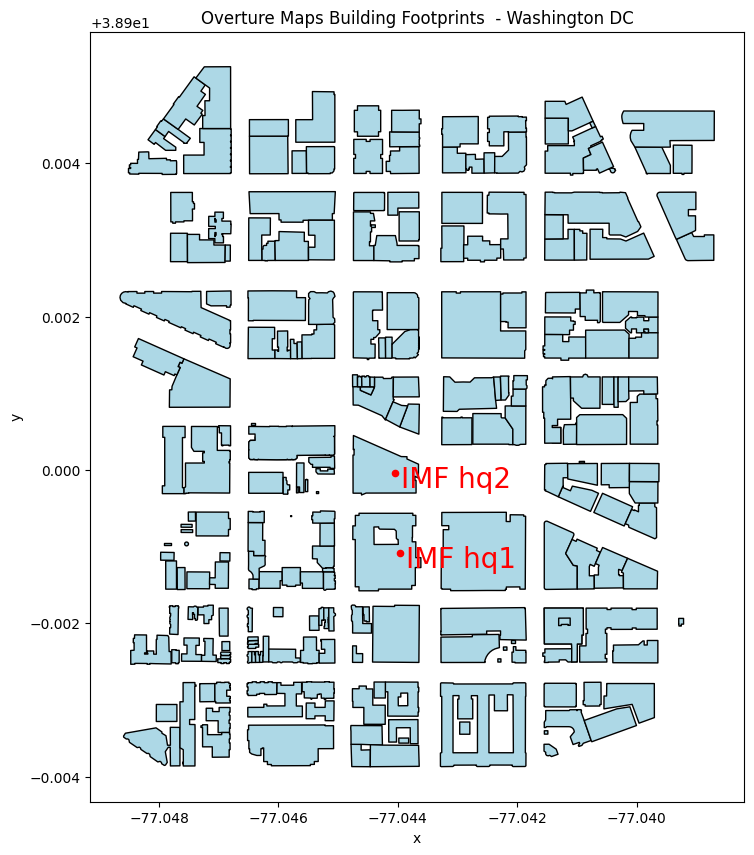

In [ ]:
# Let's define a smaller area around Tirana city center
xmin = -77.0478196131
xmax = -77.039270876
ymin = 38.8964034662
ymax = 38.9045279698

hqs = pd.DataFrame(
    {'x': [-77.043955, -77.044042],
     'y': [38.898922, 38.899961],
     'labels': ['IMF hq1', 'IMF hq2']})

fig, ax = plt.subplots(figsize=(10, 10))

# Plot the building footprints filtered within the bounding box
overture_gdf.cx[xmin:xmax, ymin:ymax].plot(ax=ax,
                  edgecolor="black",
                  facecolor="lightblue")

hqs.plot.scatter(x='x', y='y', ax=ax, color='red')
for i, row in hqs.iterrows():
    ax.text(row['x']+ 0.0001,     # horizontal padding
            row['y']+ 0.0001,     # vertical padding
            row['labels'], fontsize=20, ha='left', va='top', color='red')


# # Show the plot
plt.title("Overture Maps Building Footprints  - Washington DC")
plt.show()

In [ ]:
overture_gdf.cx[xmin:xmax, ymin:ymax].explore()

### Building Properties

| Property | Type | Description |
|---|---|---|
| `id` | string | Stable Overture feature identifier (128-bit string). |
| `version` | integer | Incremented when the feature changes. |
| `names` | object | Optional multilingual names; includes `primary`, `common` (by lang), and `rules` (variants). |
| `level` | integer | Vertical level for stacking/ordering (usually `1` for footprints). |
| `subtype` | enum(string) | Broad building purpose (e.g., `residential`, `commercial`, `industrial`, `education`, `medical`, `religious`, `transportation`, etc.). |
| `class` | enum(string) | Finer category (e.g., `house`, `apartments`, `office`, `warehouse`, `school`, `hospital`, `parking`, `temple`, …). |
| `has_parts` | boolean | `true` if the building has related `building_part` features. |
| `height` | number | Overall building height (SI units; meters). |
| `num_floors` | integer | Count of above-ground floors. |
| `num_floors_underground` | integer | Count of below-ground floors. |
| `is_underground` | boolean | `true` if the structure is underground. |
| `roof_height` | number | Height of roof structure (if available). |
| `roof_shape` | enum(string) | Roof form (e.g., `flat`, `gabled`, `hipped`, …). |
| `roof_material` | enum(string) | Roof material (e.g., `metal`, `tile`, `concrete`, …). |
| `facade_material` | enum(string) | Exterior wall material (e.g., `brick`, `stone`, `wood`, …). |
| `sources` | array(object) | Provenance per property; each item has `dataset`, `property` (JSON-pointer to the field), and `confidence` (0–1). |
| `ext_*` | any | Customer/user extensions (namespaced as `ext_…`). |

> **Notes**
> - Many attributes (subtype/class/materials) are harmonized from **OSM tags** and other providers into fixed enumerations defined by the schema.  
> - Measurements follow **SI units** and are provided as scalars **without unit strings**.  
> - If a building has internal segmentation (e.g., wings/sections), those appear as separate features under **`building_part`** with similar shape/height properties.

**Docs:** See the official [schema pages](https://docs.overturemaps.org/schema/concepts/by-theme/buildings/) for full enums and examples

Number of records missing subtype: 141553, 43%



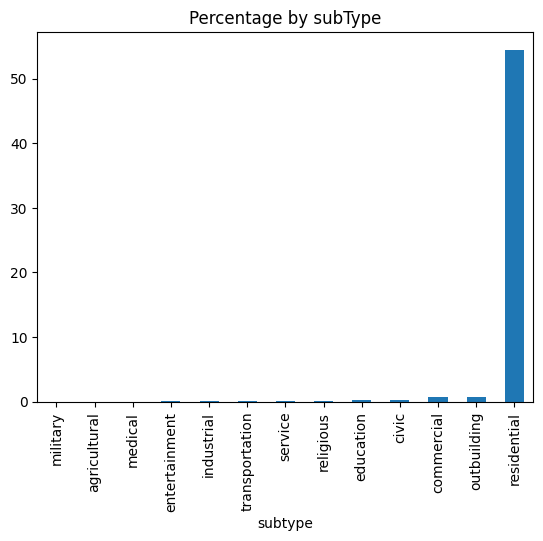

In [ ]:
# Different types of buildings
print(f"Number of records missing subtype: {overture_gdf['subtype'].isna().sum()}, {round(overture_gdf['subtype'].isna().sum()*100/overture_gdf.shape[0])}%")
print()
(overture_gdf
  .groupby('subtype').size()
  .sort_values()*100/overture_gdf.shape[0]).plot(
    kind='bar', title="Percentage by subType");

In [ ]:
building_properties = ['height', 'has_parts', 'is_underground', 'num_floors',
                      'num_floors_underground', 'min_height', 'min_floor', 'facade_color',
                      'facade_material', 'roof_material', 'roof_shape', 'roof_direction',
                      'roof_orientation', 'roof_color', 'roof_height']

(overture_gdf[overture_gdf.subtype=="residential"][building_properties].isna().sum()*100 /
 overture_gdf[overture_gdf.subtype=="residential"].shape[0]).to_frame(name="Percentage of NAs")

,Percentage of NAs
height,53.443014
has_parts,0.000000
is_underground,0.000000
num_floors,69.372659
num_floors_underground,99.994400
min_height,100.000000
min_floor,99.999440
facade_color,99.995520
facade_material,99.889685
roof_material,99.994960


### H3 binning

In [ ]:
h3_level = 10 # ≈ 13.6 km²

# Convert lat/long centroids of each building footprint into the coresponding h3 cell ID
def lat_lng_to_h3(row):
    return h3.latlng_to_cell(
      row.geometry.centroid.y, row.geometry.centroid.x, h3_level)

overture_gdf[f'h3_level_{h3_level}'] = overture_gdf.apply(lat_lng_to_h3, axis=1)


In [ ]:
overture_gdf = overture_gdf[overture_gdf.within(aoi_shape)]

In [ ]:
overture_gdf.head()

,id,geometry,bbox,version,sources,level,subtype,class,height,names,...,min_floor,facade_color,facade_material,roof_material,roof_shape,roof_direction,roof_orientation,roof_color,roof_height,h3_level_10
24051,43d4753c-9965-49dc-8a47-3fefa9c18ebc,"POLYGON ((-77.0262 38.81117, -77.02634 38.8115...","{'xmin': -77.02656555175781, 'xmax': -77.02619...",1,"[{'property': '', 'dataset': 'Esri Community M...",NaN,None,None,NaN,None,...,NaN,None,None,None,None,NaN,None,None,NaN,8a2aa8780947fff
24052,463c17a3-eb8a-4786-be73-aa65bcbb61ea,"POLYGON ((-77.02534 38.81186, -77.02534 38.811...","{'xmin': -77.02534484863281, 'xmax': -77.02511...",1,"[{'property': '', 'dataset': 'OpenStreetMap', ...",NaN,None,None,NaN,None,...,NaN,None,None,None,None,NaN,None,None,NaN,8a2aa8785597fff
24056,7a609fd0-daec-4686-8282-f292327edc7a,"POLYGON ((-77.02602 38.81198, -77.02602 38.811...","{'xmin': -77.02610778808594, 'xmax': -77.02601...",1,"[{'property': '', 'dataset': 'Esri Community M...",NaN,None,None,NaN,None,...,NaN,None,None,None,None,NaN,None,None,NaN,8a2aa8780967fff
24057,8be02361-8df9-4b06-b87a-2194a0454334,"POLYGON ((-77.02607 38.81213, -77.02602 38.811...","{'xmin': -77.02606964111328, 'xmax': -77.02597...",1,"[{'property': '', 'dataset': 'Esri Community M...",NaN,None,None,NaN,None,...,NaN,None,None,None,None,NaN,None,None,NaN,8a2aa8780967fff
24058,d6e96234-b878-4440-aee5-2f5f478bad57,"POLYGON ((-77.02602 38.81229, -77.02599 38.812...","{'xmin': -77.02603149414062, 'xmax': -77.02599...",1,"[{'property': '', 'dataset': 'Esri Community M...",NaN,None,None,NaN,None,...,NaN,None,None,None,None,NaN,None,None,NaN,8a2aa8780967fff


In [ ]:
# Count number of buildings by H3 cell
om_n_buildings_by_h3 = (
    overture_gdf.groupby([f'h3_level_{h3_level}'])
    .agg(
        {'height': 'mean',
         'id': 'count',
         'subtype': pd.Series.mode}
    )
    .reset_index()
    .rename(columns={'id': 'n_buildings'})
)

print(om_n_buildings_by_h3.shape)

om_n_buildings_by_h3.head()

(8948, 4)


,h3_level_10,height,n_buildings,subtype
0,8a2aa8408247fff,NaN,1,[]
1,8a2aa840824ffff,5.312768,12,residential
2,8a2aa8408257fff,6.320000,6,residential
3,8a2aa840825ffff,6.631020,16,residential
4,8a2aa84082cffff,4.844448,6,residential


In [ ]:
# Add geometry of the hexbins
om_n_buildings_by_h3['geometry'] = om_n_buildings_by_h3.h3_level_10.apply(lambda x: h3.cells_to_geo([x]))
om_n_buildings_by_h3['geometry'] = om_n_buildings_by_h3['geometry'].apply(geometry.shape)

# Convert into geopandas dataframe
om_n_buildings_by_h3_geo = gpd.GeoDataFrame(
    om_n_buildings_by_h3,
    geometry='geometry',
    crs=4326
)

om_n_buildings_by_h3_geo.head()

,h3_level_10,height,n_buildings,subtype,geometry
0,8a2aa8408247fff,NaN,1,[],"POLYGON ((-77.04042 38.99486, -77.04065 38.994..."
1,8a2aa840824ffff,5.312768,12,residential,"POLYGON ((-77.03874 38.99285, -77.0385 38.9934..."
2,8a2aa8408257fff,6.320000,6,residential,"POLYGON ((-77.04106 38.99532, -77.04193 38.995..."
3,8a2aa840825ffff,6.631020,16,residential,"POLYGON ((-77.04065 38.99423, -77.04152 38.994..."
4,8a2aa84082cffff,4.844448,6,residential,"POLYGON ((-77.04326 38.99372, -77.04413 38.993..."


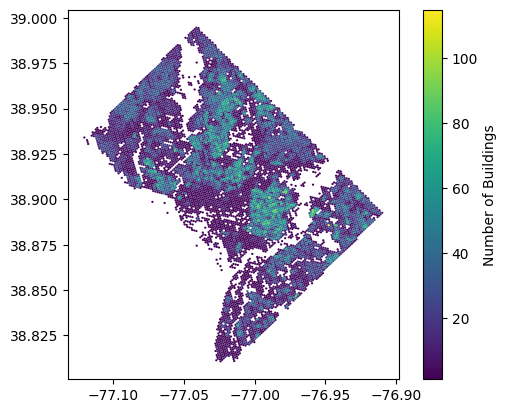

In [ ]:
# Plot number of buildings by h3 on a map
om_n_buildings_by_h3_geo.plot(column="n_buildings",
                           legend=True,
                           legend_kwds={"label": "Number of Buildings"});

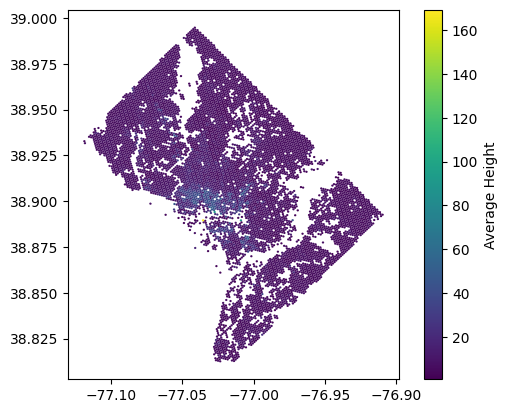

In [ ]:
# Plot avg height by h3 on a map
om_n_buildings_by_h3_geo[~om_n_buildings_by_h3_geo.height.isna()].plot(column="height",
                           legend=True,
                           legend_kwds={"label": "Average Height"});

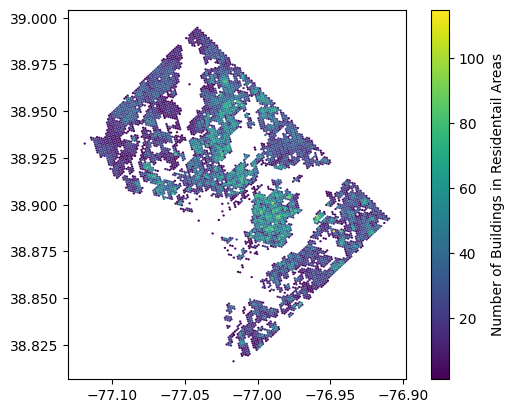

In [ ]:
# Plot number of buildings by h3 on a map
om_n_buildings_by_h3_geo[om_n_buildings_by_h3_geo.subtype.astype(str)=="residential"].plot(column="n_buildings",
                           legend=True,
                           legend_kwds={"label": "Number of Buildings in Residentail Areas"});